In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# ADD these:
import mlflow
import mlflow.pytorch
from datetime import datetime


transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Create datasets for training & validation, download if necessary
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Create data loaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Report split sizes
print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

Training set has 60000 instances
Validation set has 10000 instances


Sandal  Sneaker  T-shirt/top  Dress


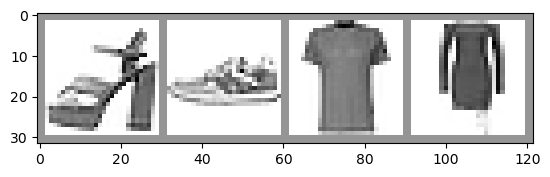

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [3]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

In [4]:
loss_fn = torch.nn.CrossEntropyLoss()

# NB: Loss functions expect data in batches, so we're creating batches of 4
# Represents the model's confidence in each of the 10 classes for a given input
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.0152, 0.7350, 0.5267, 0.5100, 0.2390, 0.4750, 0.9334, 0.6569, 0.6334,
         0.7619],
        [0.1904, 0.6311, 0.7184, 0.2211, 0.8872, 0.6130, 0.0408, 0.6420, 0.2392,
         0.1923],
        [0.6507, 0.5087, 0.7934, 0.1098, 0.4802, 0.5905, 0.2968, 0.6822, 0.7964,
         0.0945],
        [0.7669, 0.0078, 0.0958, 0.2474, 0.2498, 0.4611, 0.2508, 0.3903, 0.2562,
         0.7870]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.331948757171631


In [5]:
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# ADD:
EPOCHS = 5
hparams = {
    "epochs": EPOCHS,
    "batch_size": 4,
    "lr": 0.001,
    "momentum": 0.9,
    "optimizer": "SGD",
    "loss_fn": "CrossEntropyLoss",
}

In [6]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            step = epoch_index * len(training_loader) + i + 1
            mlflow.log_metric('train_batch_loss', last_loss, step=step)
            running_loss = 0.

    return last_loss

In [8]:
# REMOVE all the TensorBoard writer/timestamp stuff
# REPLACE the whole cell with:

mlflow.set_experiment("Assignment_3_Mohamed_Hozien")

with mlflow.start_run():
    # Log hyperparameters
    mlflow.log_params(hparams)

    best_vloss = 1_000_000.

    for epoch in range(EPOCHS):
        print('EPOCH {}:'.format(epoch + 1))

        model.train(True)
        avg_loss = train_one_epoch(epoch)       # <-- no writer arg

        running_vloss = 0.0
        model.eval()
        with torch.no_grad():
            for i, vdata in enumerate(validation_loader):
                vinputs, vlabels = vdata
                voutputs = model(vinputs)
                vloss = loss_fn(voutputs, vlabels)
                running_vloss += vloss

        avg_vloss = (running_vloss / (i + 1)).item()

        print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

        # Log epoch-level metrics to MLflow
        mlflow.log_metric('train_loss', avg_loss, step=epoch + 1)
        mlflow.log_metric('val_loss', avg_vloss, step=epoch + 1)

        # Track best performance and save model
        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            model_path = 'best_model.pth'
            torch.save(model.state_dict(), model_path)

    # Log final metrics
    mlflow.log_metric('best_val_loss', best_vloss)

    # Log the best model as an MLflow artifact
    mlflow.pytorch.log_model(model, "model")

    # Also log the .pth file if you want the raw state dict
    mlflow.log_artifact(model_path)

    print("MLflow run ID:", mlflow.active_run().info.run_id)

EPOCH 1:
  batch 1000 loss: 0.254911831423422
  batch 2000 loss: 0.2676842618901037
  batch 3000 loss: 0.25876432693526297
  batch 4000 loss: 0.26749181576780395
  batch 5000 loss: 0.26123999708863993
  batch 6000 loss: 0.25882315600321454
  batch 7000 loss: 0.2661137099953994
  batch 8000 loss: 0.27026946217528985
  batch 9000 loss: 0.26287208488733743
  batch 10000 loss: 0.29917252152939183
  batch 11000 loss: 0.26984274777374184
  batch 12000 loss: 0.27932456015972185
  batch 13000 loss: 0.2613129112359893
  batch 14000 loss: 0.267147480755576
  batch 15000 loss: 0.27209741768207824
LOSS train 0.27209741768207824 valid 0.30041050910949707
EPOCH 2:
  batch 1000 loss: 0.2304426106576102
  batch 2000 loss: 0.23846194273267793
  batch 3000 loss: 0.2588236504205033
  batch 4000 loss: 0.26007067946563256
  batch 5000 loss: 0.26774072590626385
  batch 6000 loss: 0.25436742903494247
  batch 7000 loss: 0.2409971124447675
  batch 8000 loss: 0.24712013577364497
  batch 9000 loss: 0.25881401468

2026/03/09 23:33:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 23:33:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


LOSS train 0.22786754757724567 valid 0.31658101081848145
MLflow run ID: 805991e73c4e4c2eaea6ccb9ced4e5cc


In [9]:
saved_model = GarmentClassifier()
saved_model.load_state_dict(torch.load(model_path))

C:\Users\midoh\AppData\Local\Temp\ipykernel_84460\438420676.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [12]:
saved_model = mlflow.pytorch.load_model("runs:/805991e73c4e4c2eaea6ccb9ced4e5cc/model")